# **League of Legends Prediction Project**




## Load Dataset & Initial Inspection

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/MLproject/2020_LoL_esports_match_data_from_OraclesElixir_20200913.csv')

## Data Cleaning

In [4]:
#Data information
print(f"The 'data' variable (a DataFrame) has been successfully loaded.")
df = data
display(df.head())
df.shape
df.dtypes
df.describe()
df.isna().sum().sort_values(ascending=False)

The 'data' variable (a DataFrame) has been successfully loaded.


,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,csdiffat10,goldat15,xpat15,csat15,opp_goldat15,opp_xpat15,opp_csat15,golddiffat15,xpdiffat15,csdiffat15
0,ESPORTSTMNT03/1241318,complete,http://matchhistory.na.leagueoflegends.com/en/...,KeSPA,2020,NaN,0,2020-01-03 07:33:26,1,9.24,...,23.0,4888.0,7368.0,131.0,4723.0,7202.0,118.0,165.0,166.0,13.0
1,ESPORTSTMNT03/1241318,complete,http://matchhistory.na.leagueoflegends.com/en/...,KeSPA,2020,NaN,0,2020-01-03 07:33:26,1,9.24,...,-10.0,4385.0,4817.0,91.0,4784.0,4667.0,98.0,-399.0,150.0,-7.0
2,ESPORTSTMNT03/1241318,complete,http://matchhistory.na.leagueoflegends.com/en/...,KeSPA,2020,NaN,0,2020-01-03 07:33:26,1,9.24,...,-9.0,4809.0,6275.0,129.0,5218.0,8112.0,140.0,-409.0,-1837.0,-11.0
3,ESPORTSTMNT03/1241318,complete,http://matchhistory.na.leagueoflegends.com/en/...,KeSPA,2020,NaN,0,2020-01-03 07:33:26,1,9.24,...,3.0,4915.0,4959.0,136.0,4864.0,5360.0,135.0,51.0,-401.0,1.0
4,ESPORTSTMNT03/1241318,complete,http://matchhistory.na.leagueoflegends.com/en/...,KeSPA,2020,NaN,0,2020-01-03 07:33:26,1,9.24,...,1.0,2956.0,3800.0,20.0,3189.0,3543.0,28.0,-233.0,257.0,-8.0


,0
dragons (type unknown),63809
firstbaron,57068
mountains,56850
elementaldrakes,56850
opp_elementaldrakes,56850
...,...
monsterkillsownjungle,0
earnedgold,0
totalgold,0
monsterkills,0


In [5]:
#Handle Missing Values with median
numerical_cols = df.select_dtypes(include=['number']).columns
median_values = df[numerical_cols].median()
df.loc[:, numerical_cols] = df[numerical_cols].fillna(median_values)

# Handle Missing Values with mode
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    mode_values = df[categorical_cols].mode().iloc[0]
    df.loc[:, categorical_cols] = df[categorical_cols].fillna(mode_values)

# Drop Irrelevant Columns
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("After missing-value handling:", df.shape)


After missing-value handling: (67980, 103)


In [6]:
#Duplicate Removal
df.duplicated()
num_columns=df.select_dtypes(include=["int64","float64"]).columns
df = df.drop_duplicates()

#Scaling
scaler=StandardScaler()
df[num_columns]=scaler.fit_transform(df[num_columns])
print(df[num_columns].head())
df.to_csv("scaled_dataset.csv",index=False)

       year  playoffs      game      patch  playerid  gamelength  result  \
0 -0.037606 -0.386722 -0.669365 -14.588917 -0.495804    0.757908     1.0   
1 -0.037606 -0.386722 -0.669365 -14.588917 -0.478458    0.757908     1.0   
2 -0.037606 -0.386722 -0.669365 -14.588917 -0.461112    0.757908     1.0   
3 -0.037606 -0.386722 -0.669365 -14.588917 -0.443766    0.757908     1.0   
4 -0.037606 -0.386722 -0.669365 -14.588917 -0.426420    0.757908     1.0   

      kills    deaths   assists  ...  csdiffat10  goldat15    xpat15  \
0 -0.811472 -0.269003 -0.255062  ...    1.258227 -0.441060 -0.258207   
1 -0.071271 -0.848434 -0.090459  ...   -0.547055 -0.509416 -0.551060   
2  0.113780 -0.462147 -0.419664  ...   -0.492350 -0.451796 -0.383683   
3  0.483880 -0.655291 -0.090459  ...    0.164117 -0.437391 -0.534758   
4 -0.626422  0.117284 -0.584267  ...    0.054706 -0.703611 -0.667810   

     csat15  opp_goldat15  opp_xpat15  opp_csat15  golddiffat15  xpdiffat15  \
0 -0.225861     -0.463483   -0.

In [7]:
#Encoding
print("Rows BEFORE encoding:", df.shape)
def encoding(df):
#drop columns
    df = df.drop(columns=[
        'gameid',
        'url',
        'datacompleteness',
        'player',
        'date'
    ], errors='ignore')

#feature engineering
    df['gold_diff_15'] = df['golddiffat15']

    df['xp_diff_15'] = df['xpdiffat15']

    df['gold_per_min'] = df['totalgold'] / (df['gamelength'] / 60)
#labled encoding
    label_cols = [
        'league',
        'team',
        'champion',
        'position',
        'split',
        'ban1', 'ban2', 'ban3', 'ban4', 'ban5'
    ]

    le = LabelEncoder()
    for col in label_cols:
        df[col] = le.fit_transform(df[col].astype(str))
# one-hot encoding
    df = pd.get_dummies(df, columns=['side'], drop_first=True)

    return df

Rows BEFORE encoding: (67980, 103)


In [8]:
df = encoding(df)

## Feature selection & filtering

In [9]:
# feature filtering
early_game_features = [
    'goldat10', 'golddiffat10',
    'xpat10', 'xpdiffat10',
    'csat10', 'csdiffat10',
    'goldat15', 'golddiffat15',
    'xpat15', 'xpdiffat15',
    'csat15', 'csdiffat15',
    'firstblood', 'firstdragon', 'firstherald', 'firsttower',
    'kills', 'assists', 'deaths',
    'minionkills', 'cspm',
    'result'
]

df = df[early_game_features]


In [10]:
#feature selection
def feature_selection(df):
    numeric_df = df.select_dtypes(include=['int64','float64'])

    corr_matrix = numeric_df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.9)]

    df2 = df.drop(columns=to_drop_corr, errors='ignore')

    numeric_df2 = df2.select_dtypes(include=['int64','float64'])
    selector = VarianceThreshold(threshold=0.0)
    selector.fit(numeric_df2)
    kept = numeric_df2.columns[selector.get_support(indices=True)]

    df_final = df2[kept]

    print("Dropped due to correlation:", to_drop_corr)
    print("Kept features:", list(kept))

    return df_final

selected_data = feature_selection(df)

Dropped due to correlation: ['xpat10', 'csat10', 'goldat15', 'xpat15', 'csat15', 'cspm']
Kept features: ['goldat10', 'golddiffat10', 'xpdiffat10', 'csdiffat10', 'golddiffat15', 'xpdiffat15', 'csdiffat15', 'firstblood', 'firstdragon', 'firstherald', 'firsttower', 'kills', 'assists', 'deaths', 'minionkills', 'result']


In [11]:
selected_data.head()
# Clean after Feature Selection
selected_data = selected_data.replace([np.inf, -np.inf], 0)
selected_data = selected_data.fillna(0)
print("Final selected_data shape:", selected_data.shape)


Final selected_data shape: (67980, 16)


##train, test & split

In [12]:
X = selected_data.drop('result', axis=1)
y = selected_data['result']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [14]:
#split data
X = selected_data.drop('result', axis=1)
y = selected_data['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## Models Training (supervised)

In [15]:
#LogisticRegressionModel

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8884230656075316

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.89      0.89      0.89      6798
         1.0       0.89      0.89      0.89      6798

    accuracy                           0.89     13596
   macro avg       0.89      0.89      0.89     13596
weighted avg       0.89      0.89      0.89     13596


Confusion Matrix:
[[6043  755]
 [ 762 6036]]


|--- assists <= -0.46
|   |--- deaths <= -0.56
|   |   |--- kills <= -0.35
|   |   |   |--- assists <= -0.63
|   |   |   |   |--- deaths <= -0.75
|   |   |   |   |   |--- class: -1.0
|   |   |   |   |--- deaths >  -0.75
|   |   |   |   |   |--- class: -1.0
|   |   |   |--- assists >  -0.63
|   |   |   |   |--- deaths <= -0.75
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- deaths >  -0.75
|   |   |   |   |   |--- class: -1.0
|   |   |--- kills >  -0.35
|   |   |   |--- kills <= 0.21
|   |   |   |   |--- deaths <= -0.75
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- deaths >  -0.75
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- kills >  0.21
|   |   |   |   |--- csdiffat15 <= 0.78
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- csdiffat15 >  0.78
|   |   |   |   |   |--- class: 1.0
|   |--- deaths >  -0.56
|   |   |--- kills <= -0.35
|   |   |   |--- assists <= -0.63
|   |   |   |   |--- deaths <= -0.17
|   |   |   |   |   |--- class: -1.0
|   |   |   |

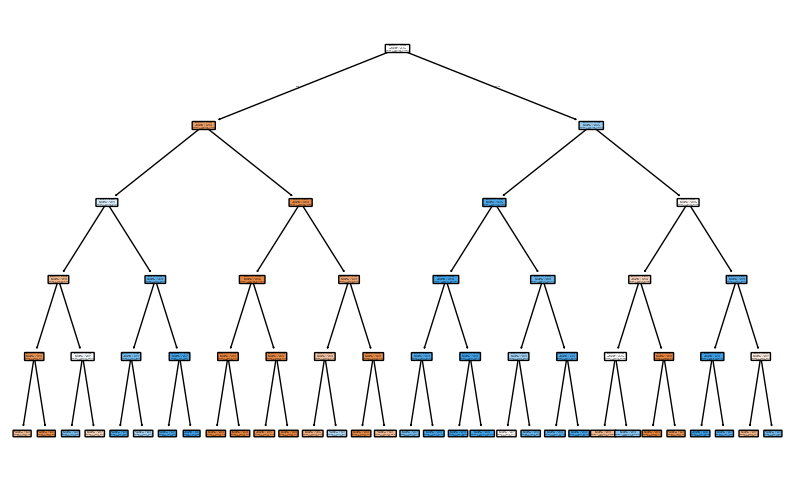

In [16]:
#DecisionTree
clf = DecisionTreeClassifier(criterion='entropy',
                            max_depth = 5,
                             min_samples_split=20,
                             random_state=0
)
clf.fit(X_train, y_train)

tree_rules = export_text(clf, feature_names=list(X_train.columns))
print(tree_rules)

plt.figure(figsize=(10, 6))
plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)
plt.show()

## Models Testing (supervised)

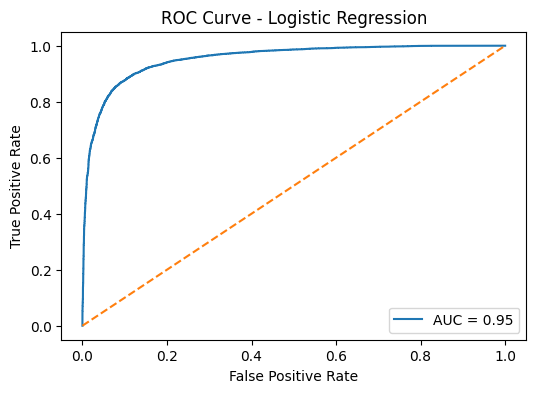

In [17]:
#logistic regression model
y_prob = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Decision Tree Accuracy:
 0.866504854368932


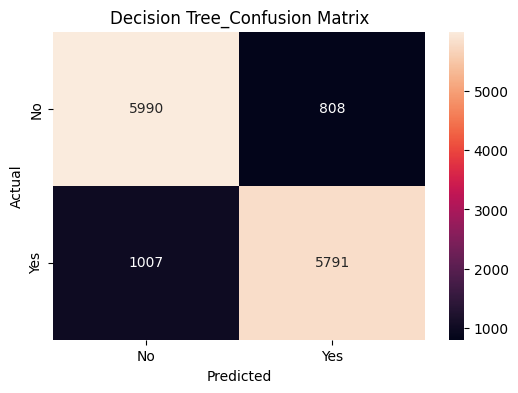

Classification Report:

              precision    recall  f1-score   support

          No       0.86      0.88      0.87      6798
         Yes       0.88      0.85      0.86      6798

    accuracy                           0.87     13596
   macro avg       0.87      0.87      0.87     13596
weighted avg       0.87      0.87      0.87     13596



In [18]:
#DecisionTree
y_pred_dt=clf.predict(X_test)
accuracy_dt=accuracy_score(y_test, y_pred_dt)

#Accuracy
print("Decision Tree Accuracy:\n",accuracy_dt)

#Confusion Matrix
cm=confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True,fmt="d",xticklabels=['No','Yes'],yticklabels=['No','Yes'])
plt.title("Decision Tree_Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_dt,target_names=['No','Yes']))

## Results Comparison & Visualization

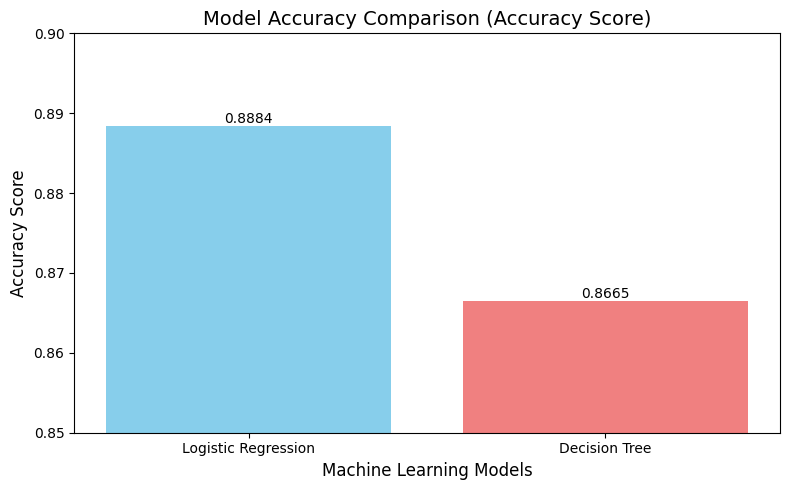

In [19]:
# Models
models = ['Logistic Regression', 'Decision Tree']

accuracies = [accuracy_lr, accuracy_dt]


plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f"{height:.4f}", ha='center', va='bottom')

plt.ylim(0.85, 0.90)
plt.title("Model Accuracy Comparison (Accuracy Score)", fontsize=14)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.tight_layout()
plt.savefig("model_accuracy_comparison.png")
plt.show()

##Models training ( Unsupervised )

Silhouette score: 0.5892644081660879


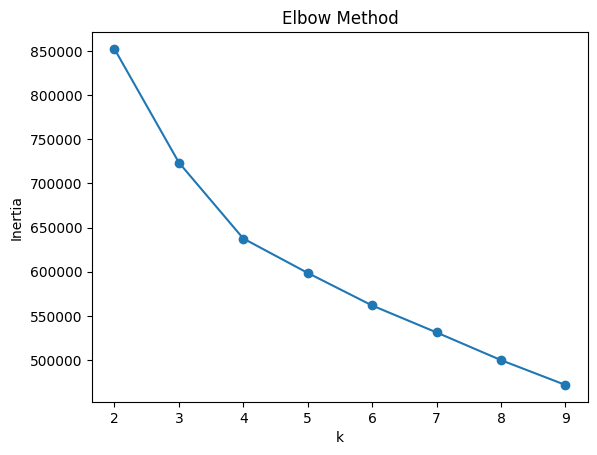

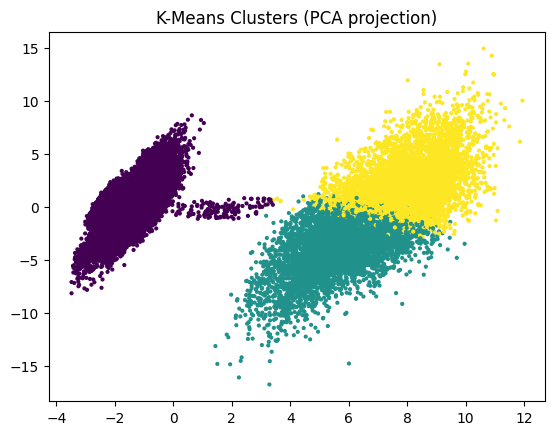

In [20]:
#k-mean

X_cluster=df.select_dtypes(include='number').values

kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)

labels=kmeans.fit_predict(X_cluster)

score=silhouette_score(X_cluster, labels)
print("Silhouette score:", score)

inertia=[]
Ks=range(2,10)

for k in Ks:
    model=KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_cluster)
    inertia.append(model.inertia_)

plt.plot(Ks, inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

#----------PCA----------

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_cluster)

plt.scatter(X_2d[:,0],X_2d[:,1],c=labels,cmap="viridis",s=4)
plt.title("K-Means Clusters (PCA projection)")
plt.show()


